# Perceptron Learning Algorithm for AND Gate

## Aim
To implement the Perceptron Learning Algorithm for the AND logic gate using Python, display the weights after each update, and visualize the decision boundary after every weight update.

## Description
The AND gate produces an output of **1** only when both inputs are **1**; otherwise, the output is **0**.

The perceptron is initialized with zero weights and bias. During training, it computes the weighted sum of the inputs and applies the step activation function to predict the output. Whenever the prediction differs from the target output, the weights and bias are updated using the perceptron learning rule.

Throughout the training process, the program:
- Displays the weights and bias after every update.
- Plots the decision boundary after each weight update.
- Calculates the training accuracy after every epoch.
- Records the complete history of weight updates.
- Displays the final weights, bias, predictions, and decision boundary after convergence.

The perceptron successfully converges because the AND gate is a **linearly separable** problem.

INITIAL MODEL
Weights = [0. 0.]
Bias = 0

EPOCH 1
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [0. 0.]             0

Weight Updated
New Weights = [0. 0.]
New Bias    = -1
[0 1]     0         0         0         [0. 0.]             -1
[1 0]     0         0         0         [0. 0.]             -1
[1 1]     1         0         1         [0. 0.]             -1

Weight Updated
New Weights = [1. 1.]
New Bias    = 0



Epoch 1 Accuracy = 25.00%

EPOCH 2
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [1. 1.]             0

Weight Updated
New Weights = [1. 1.]
New Bias    = -1


[0 1]     0         1         -1        [1. 1.]             -1

Weight Updated
New Weights = [1. 0.]
New Bias    = -2


[1 0]     0         0         0         [1. 0.]             -2
[1 1]     1         0         1         [1. 0.]             -2

Weight Updated
New Weights = [2. 1.]
New Bias    = -1

Epoch 2 Accuracy = 50.00%

EPOCH 3
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [2. 1.]             -1
[0 1]     0         1         -1        [2. 1.]             -1

Weight Updated
New Weights = [2. 0.]
New Bias    = -2


[1 0]     0         1         -1        [2. 0.]             -2

Weight Updated
New Weights = [1. 0.]
New Bias    = -3
[1 1]     1         0         1         [1. 0.]             -3

Weight Updated
New Weights = [2. 1.]
New Bias    = -2



Epoch 3 Accuracy = 75.00%

EPOCH 4
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [2. 1.]             -2
[0 1]     0         0         0         [2. 1.]             -2
[1 0]     0         1         -1        [2. 1.]             -2

Weight Updated
New Weights = [1. 1.]
New Bias    = -3
[1 1]     1         0         1         [1. 1.]             -3

Weight Updated
New Weights = [2. 2.]
New Bias    = -2



Epoch 4 Accuracy = 50.00%

EPOCH 5
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [2. 2.]             -2
[0 1]     0         1         -1        [2. 2.]             -2

Weight Updated
New Weights = [2. 1.]
New Bias    = -3
[1 0]     0         0         0         [2. 1.]             -3
[1 1]     1         1         0         [2. 1.]             -3

Epoch 5 Accuracy = 100.00%

EPOCH 6
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [2. 1.]             -3
[0 1]     0         0         0         [2. 1.]             -3
[1 0]     0         0         0         [2. 1.]             -3
[1 1]     1         1         0         [2. 1.]             -3

Epoch 6 Accuracy = 100.00%

Perceptron Converged Successfully!


WEIGHT UPD

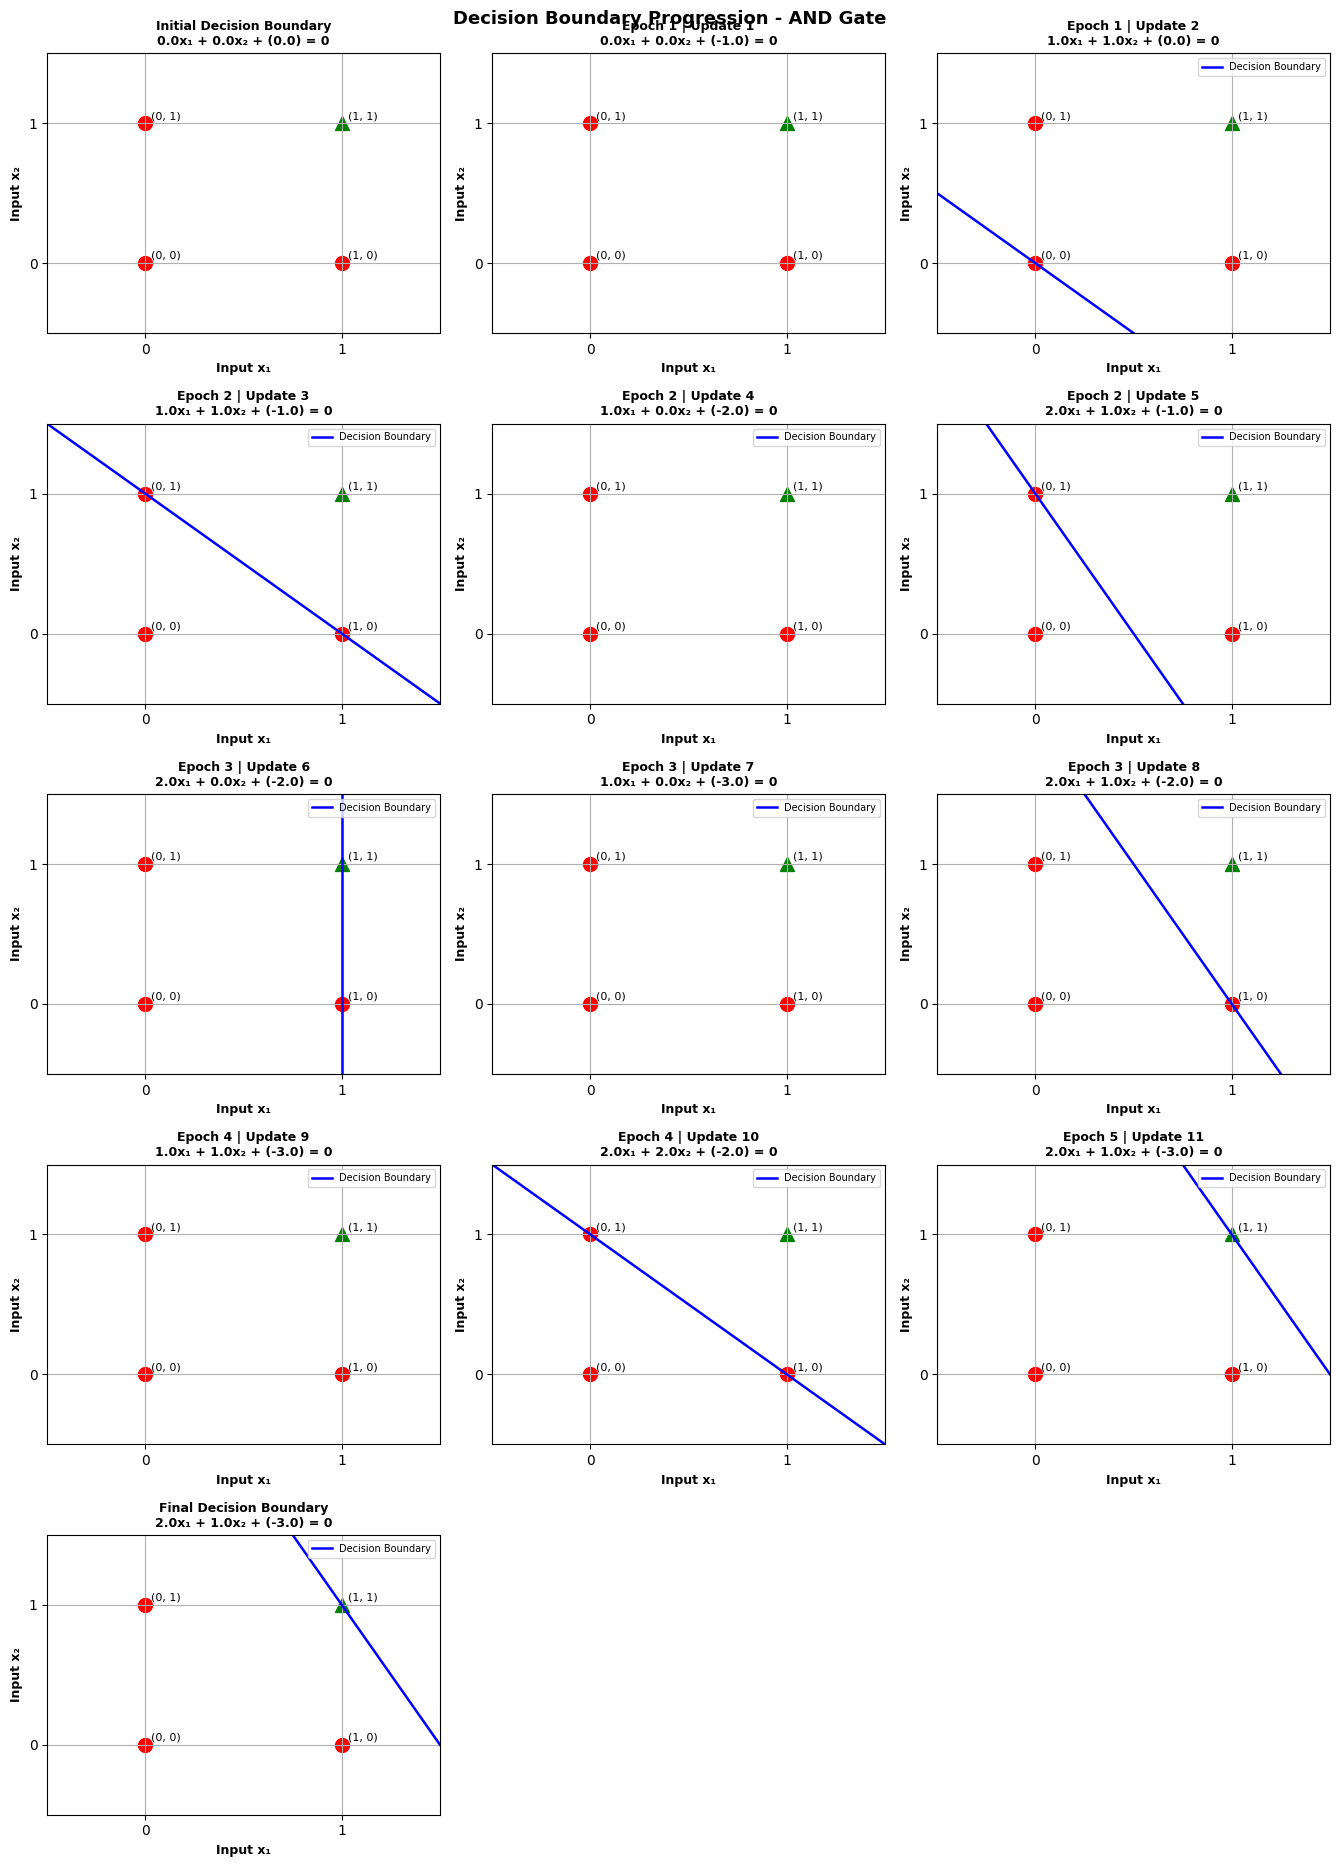

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# PERCEPTRON LEARNING ALGORITHM FOR AND GATE
# ==========================================================

# Create directory for saving EPS plots
folder_name = "and_eps_plots"
os.makedirs(folder_name, exist_ok=True)

# -----------------------------
# AND Gate Dataset
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# -----------------------------
# Parameters
# -----------------------------
learning_rate = 1
epochs = 10

# Initialize weights and bias
weights = np.zeros(2)
bias = 0

update_no = 0

# Store weight update history
history = []

# Store all decision boundaries for grid plot
plots = []

# -----------------------------
# Step Activation Function
# -----------------------------
def activation(z):
    return 1 if z >= 0 else 0


# -----------------------------
# Helper Function to Save Individual EPS Plot
# -----------------------------
def save_single_plot(w, b, title, filename):
    plt.figure(figsize=(4.5, 4.5))

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=120
        )

        plt.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=9
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:
        y_values = -(w[0] * x_values + b) / w[1]
        plt.plot(
            x_values,
            y_values,
            'b-',
            linewidth=2,
            label="Decision Boundary"
        )
    elif abs(w[0]) > 1e-6:
        x_line = -b / w[0]
        plt.axvline(
            x=x_line,
            color='blue',
            linewidth=2,
            label="Decision Boundary"
        )

    equation = f"{w[0]:.1f}x₁ + {w[1]:.1f}x₂ + ({b:.1f}) = 0"

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xticks([0, 1])
    plt.yticks([0, 1])

    plt.xlabel("Input x₁", fontsize=10, fontweight='bold')
    plt.ylabel("Input x₂", fontsize=10, fontweight='bold')

    plt.title(f"{title}\n{equation}", fontsize=11, fontweight='bold')
    plt.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        plt.legend(loc="upper right", fontsize=8)

    filepath = os.path.join(folder_name, filename)
    plt.savefig(filepath, format="eps", dpi=600, bbox_inches="tight")
    plt.close()


# -----------------------------
# Initial Model
# -----------------------------
print("="*70)
print("INITIAL MODEL")
print("="*70)
print(f"Weights = {weights}")
print(f"Bias = {bias}")

# Store initial plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Initial Decision Boundary"
))
save_single_plot(weights, bias, "Initial Decision Boundary", "initial_boundary.eps")


# -----------------------------
# Perceptron Learning
# -----------------------------
for epoch in range(epochs):

    error_count = 0

    print("\n" + "="*80)
    print(f"EPOCH {epoch+1}")
    print("="*80)

    print(f"{'Input':<10}{'Target':<10}{'Output':<10}{'Error':<10}{'Weights':<20}{'Bias'}")
    print("-"*80)

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        z = np.dot(weights, x) + bias
        prediction = activation(z)

        error = target - prediction

        print(
            f"{str(x):<10}"
            f"{target:<10}"
            f"{prediction:<10}"
            f"{error:<10}"
            f"{str(weights):<20}"
            f"{bias}"
        )

        if error != 0:

            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error

            update_no += 1

            history.append([
                update_no,
                x.copy(),
                target,
                prediction,
                error,
                weights.copy(),
                bias
            ])

            print("\nWeight Updated")
            print(f"New Weights = {weights}")
            print(f"New Bias    = {bias}")

            plot_title = f"Epoch {epoch+1} | Update {update_no}"

            # Store update plot state
            plots.append((
                weights.copy(),
                bias,
                plot_title
            ))

            # Save individual EPS plot
            save_single_plot(weights, bias, plot_title, f"update_{update_no:02d}.eps")

            error_count += 1

    # Accuracy after epoch
    correct = 0

    for i in range(len(X)):
        pred = activation(np.dot(weights, X[i]) + bias)
        if pred == y[i]:
            correct += 1

    accuracy = correct / len(X) * 100

    print(f"\nEpoch {epoch+1} Accuracy = {accuracy:.2f}%")

    if error_count == 0:
        print("\nPerceptron Converged Successfully!")
        break


# -----------------------------
# Weight Update History
# -----------------------------
print("\n")
print("="*95)
print("WEIGHT UPDATE HISTORY")
print("="*95)

print(
    f"{'Upd':<6}"
    f"{'Input':<12}"
    f"{'Target':<10}"
    f"{'Pred':<8}"
    f"{'Error':<8}"
    f"{'Weights':<22}"
    f"{'Bias'}"
)

print("-"*95)

for row in history:

    print(
        f"{row[0]:<6}"
        f"{str(row[1]):<12}"
        f"{row[2]:<10}"
        f"{row[3]:<8}"
        f"{row[4]:<8}"
        f"{str(row[5]):<22}"
        f"{row[6]}"
    )


# -----------------------------
# Final Model
# -----------------------------
print("\n")
print("="*70)
print("FINAL MODEL")
print("="*70)

print(f"Final Weights = {weights}")
print(f"Final Bias    = {bias}")


# -----------------------------
# Final Predictions
# -----------------------------
print("\n")
print("="*55)
print("FINAL PREDICTIONS")
print("="*55)

print(f"{'Input':<12}{'Target':<12}{'Prediction'}")
print("-"*55)

for i in range(len(X)):

    pred = activation(np.dot(weights, X[i]) + bias)

    print(
        f"{str(X[i]):<12}"
        f"{y[i]:<12}"
        f"{pred}"
    )

# Store final plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Final Decision Boundary"
))
save_single_plot(weights, bias, "Final Decision Boundary", "final_boundary.eps")


# ==========================================================
# ALL DECISION BOUNDARIES IN A GRID
# ==========================================================

cols = 3
rows = int(np.ceil(len(plots) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13.5, rows * 3.8))

axes = np.array(axes).reshape(-1)

for ax, (w, b, title) in zip(axes, plots):

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):

        ax.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=100
        )

        ax.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=8
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:

        y_values = -(w[0] * x_values + b) / w[1]

        ax.plot(
            x_values,
            y_values,
            'b-',
            linewidth=1.8,
            label="Decision Boundary"
        )

    elif abs(w[0]) > 1e-6:

        x_line = -b / w[0]

        ax.axvline(
            x=x_line,
            color='blue',
            linewidth=1.8,
            label="Decision Boundary"
        )

    equation = (
        f"{w[0]:.1f}x₁ + "
        f"{w[1]:.1f}x₂ + "
        f"({b:.1f}) = 0"
    )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xlabel("Input x₁", fontsize=9, fontweight='bold')
    ax.set_ylabel("Input x₂", fontsize=9, fontweight='bold')

    ax.set_title(
        f"{title}\n{equation}",
        fontsize=9,
        fontweight='bold'
    )

    ax.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        ax.legend(loc="upper right", fontsize=7)

# Hide unused subplot axes
for ax in axes[len(plots):]:
    ax.axis("off")

plt.suptitle(
    "Decision Boundary Progression - AND Gate",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save complete grid plot as vector EPS image
grid_filepath = os.path.join(folder_name, "decision_boundary_progression.eps")
plt.savefig(grid_filepath, format="eps", dpi=600, bbox_inches="tight")

plt.show()

# Perceptron Learning Algorithm for OR Gate

## Aim
To implement the Perceptron Learning Algorithm for the OR logic gate using Python, display the weights after each update, and visualize the decision boundary after every weight update.

## Description
The OR gate produces an output of **1** when at least one input is **1**; otherwise, the output is **0**.

The perceptron begins with zero weights and bias and learns the OR gate by repeatedly updating its parameters whenever an incorrect prediction is made. The weighted sum of the inputs is passed through a step activation function to generate the output.

During training, the program:
- Displays the weights and bias after every update.
- Plots the decision boundary after each weight update.
- Calculates the training accuracy after every epoch.
- Maintains a history of all weight updates.
- Displays the final weights, bias, predictions, and learned decision boundary.

Since the OR gate is **linearly separable**, the perceptron converges successfully and correctly classifies all input combinations.

INITIAL MODEL - OR GATE
Weights = [0. 0.]
Bias = 0

EPOCH 1
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [0. 0.]             0

Weight Updated
New Weights = [0. 0.]
New Bias    = -1
[0 1]     1         0         1         [0. 0.]             -1

Weight Updated
New Weights = [0. 1.]
New Bias    = 0


[1 0]     1         1         0         [0. 1.]             0
[1 1]     1         1         0         [0. 1.]             0

Epoch 1 Accuracy = 75.00%

EPOCH 2
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [0. 1.]             0

Weight Updated
New Weights = [0. 1.]
New Bias    = -1
[0 1]     1         1         0         [0. 1.]             -1
[1 0]     1         0         1         [0. 1.]             -1

Weight Updated
New Weights = [1. 1.]
New Bias    = 0


[1 1]     1         1         0         [1. 1.]             0

Epoch 2 Accuracy = 75.00%

EPOCH 3
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [1. 1.]             0

Weight Updated
New Weights = [1. 1.]
New Bias    = -1
[0 1]     1         1         0         [1. 1.]             -1
[1 0]     1         1         0         [1. 1.]             -1
[1 1]     1         1         0         [1. 1.]             -1

Epoch 3 Accuracy = 100.00%

EPOCH 4
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [1. 1.]             -1
[0 1]     1         1         0         [1. 1.]             -1
[1 0]     1         1         0         [1. 1.]             -1
[1 1]     1         1         0         [1. 1.]             -1

Epoch 4 Accura

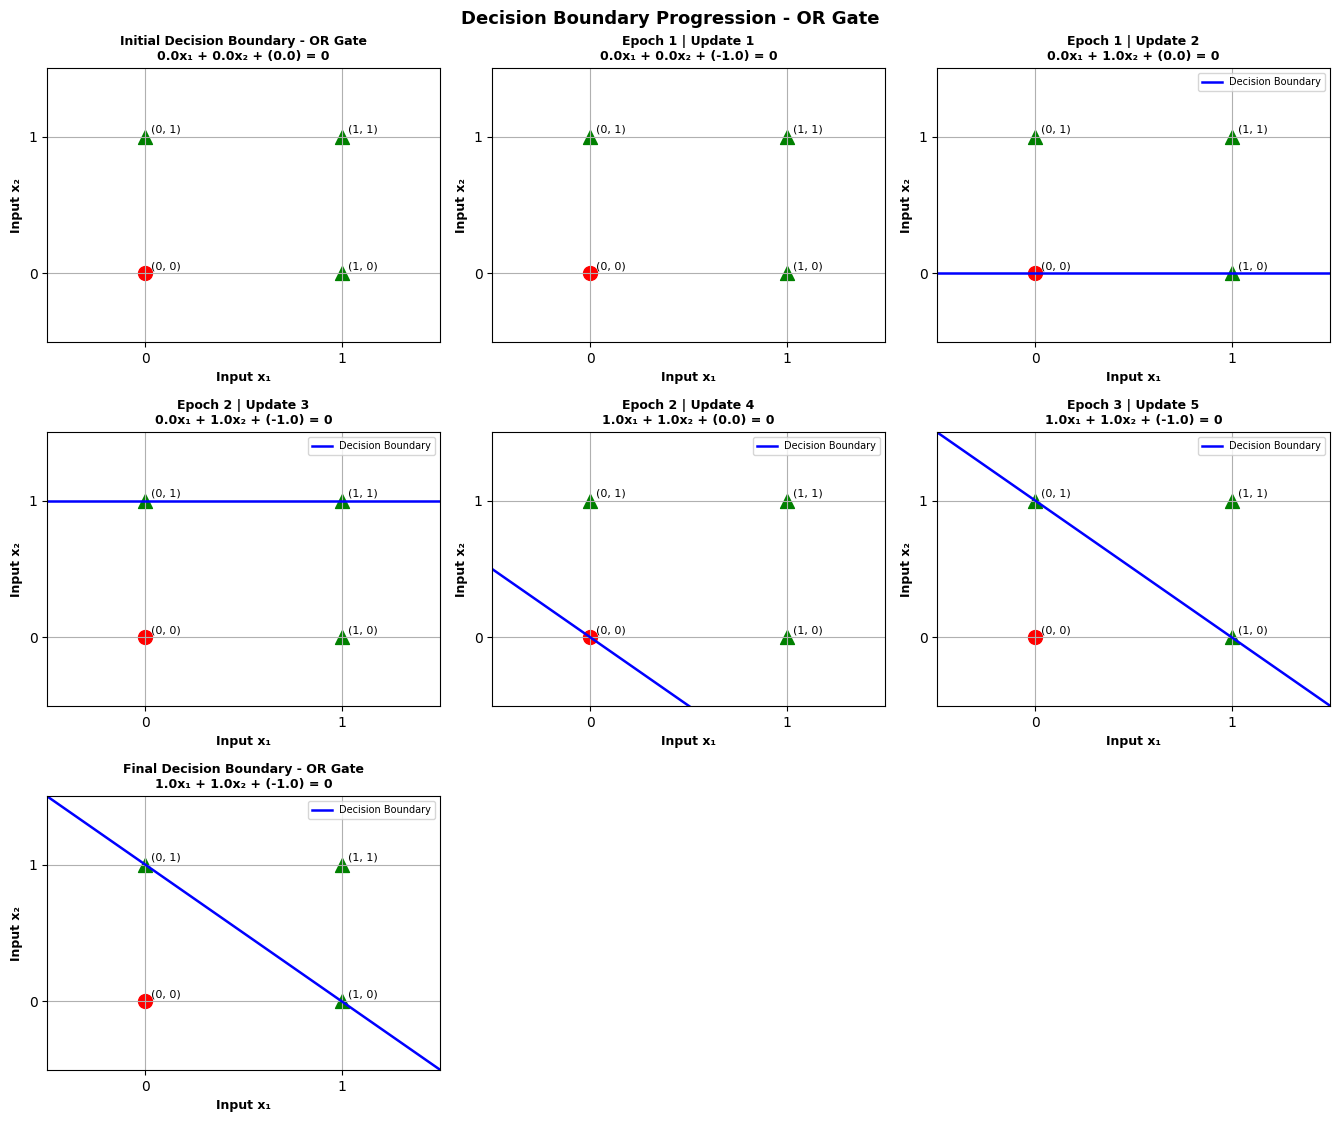

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# PERCEPTRON LEARNING ALGORITHM FOR OR GATE
# ==========================================================

# Create directory for saving EPS plots
folder_name = "or_eps_plots"
os.makedirs(folder_name, exist_ok=True)

# -----------------------------
# OR Gate Dataset
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])

# -----------------------------
# Parameters
# -----------------------------
learning_rate = 1
epochs = 10

# Initialize weights and bias
weights = np.zeros(2)
bias = 0

update_no = 0

# Store weight update history
history = []

# Store all decision boundaries for grid plot
plots = []

# -----------------------------
# Step Activation Function
# -----------------------------
def activation(z):
    return 1 if z >= 0 else 0


# -----------------------------
# Helper Function to Save Individual EPS Plot
# -----------------------------
def save_single_plot(w, b, title, filename):
    plt.figure(figsize=(4.5, 4.5))

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=120
        )

        plt.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=9
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:
        y_values = -(w[0] * x_values + b) / w[1]
        plt.plot(
            x_values,
            y_values,
            'b-',
            linewidth=2,
            label="Decision Boundary"
        )
    elif abs(w[0]) > 1e-6:
        x_line = -b / w[0]
        plt.axvline(
            x=x_line,
            color='blue',
            linewidth=2,
            label="Decision Boundary"
        )

    equation = f"{w[0]:.1f}x₁ + {w[1]:.1f}x₂ + ({b:.1f}) = 0"

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xticks([0, 1])
    plt.yticks([0, 1])

    plt.xlabel("Input x₁", fontsize=10, fontweight='bold')
    plt.ylabel("Input x₂", fontsize=10, fontweight='bold')

    plt.title(f"{title}\n{equation}", fontsize=11, fontweight='bold')
    plt.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        plt.legend(loc="upper right", fontsize=8)

    filepath = os.path.join(folder_name, filename)
    plt.savefig(filepath, format="eps", dpi=600, bbox_inches="tight")
    plt.close()


# -----------------------------
# Initial Model
# -----------------------------
print("="*70)
print("INITIAL MODEL - OR GATE")
print("="*70)
print(f"Weights = {weights}")
print(f"Bias = {bias}")

# Store initial plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Initial Decision Boundary - OR Gate"
))
save_single_plot(weights, bias, "Initial Decision Boundary - OR Gate", "initial_boundary.eps")


# -----------------------------
# Perceptron Learning
# -----------------------------
for epoch in range(epochs):

    error_count = 0

    print("\n" + "="*80)
    print(f"EPOCH {epoch+1}")
    print("="*80)

    print(f"{'Input':<10}{'Target':<10}{'Output':<10}{'Error':<10}{'Weights':<20}{'Bias'}")
    print("-"*80)

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        z = np.dot(weights, x) + bias
        prediction = activation(z)

        error = target - prediction

        print(
            f"{str(x):<10}"
            f"{target:<10}"
            f"{prediction:<10}"
            f"{error:<10}"
            f"{str(weights):<20}"
            f"{bias}"
        )

        if error != 0:

            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error

            update_no += 1

            history.append([
                update_no,
                x.copy(),
                target,
                prediction,
                error,
                weights.copy(),
                bias
            ])

            print("\nWeight Updated")
            print(f"New Weights = {weights}")
            print(f"New Bias    = {bias}")

            plot_title = f"Epoch {epoch+1} | Update {update_no}"

            # Store update plot state
            plots.append((
                weights.copy(),
                bias,
                plot_title
            ))

            # Save individual EPS plot
            save_single_plot(weights, bias, plot_title, f"update_{update_no:02d}.eps")

            error_count += 1

    # Epoch Accuracy
    correct = 0

    for i in range(len(X)):
        pred = activation(np.dot(weights, X[i]) + bias)
        if pred == y[i]:
            correct += 1

    accuracy = correct / len(X) * 100

    print(f"\nEpoch {epoch+1} Accuracy = {accuracy:.2f}%")

    if error_count == 0:
        print("\nPerceptron Converged Successfully!")
        break


# -----------------------------
# Weight Update History
# -----------------------------
print("\n")
print("="*95)
print("WEIGHT UPDATE HISTORY")
print("="*95)

print(
    f"{'Upd':<6}"
    f"{'Input':<12}"
    f"{'Target':<10}"
    f"{'Pred':<8}"
    f"{'Error':<8}"
    f"{'Weights':<22}"
    f"{'Bias'}"
)

print("-"*95)

for row in history:

    print(
        f"{row[0]:<6}"
        f"{str(row[1]):<12}"
        f"{row[2]:<10}"
        f"{row[3]:<8}"
        f"{row[4]:<8}"
        f"{str(row[5]):<22}"
        f"{row[6]}"
    )


# -----------------------------
# Final Model
# -----------------------------
print("\n")
print("="*70)
print("FINAL MODEL - OR GATE")
print("="*70)

print(f"Final Weights = {weights}")
print(f"Final Bias    = {bias}")


# -----------------------------
# Final Predictions
# -----------------------------
print("\n")
print("="*55)
print("FINAL PREDICTIONS")
print("="*55)

print(f"{'Input':<12}{'Target':<12}{'Prediction'}")
print("-"*55)

for i in range(len(X)):

    pred = activation(np.dot(weights, X[i]) + bias)

    print(
        f"{str(X[i]):<12}"
        f"{y[i]:<12}"
        f"{pred}"
    )

# Store final plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Final Decision Boundary - OR Gate"
))
save_single_plot(weights, bias, "Final Decision Boundary - OR Gate", "final_boundary.eps")


# ==========================================================
# ALL DECISION BOUNDARIES IN A GRID
# ==========================================================

cols = 3
rows = int(np.ceil(len(plots) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13.5, rows * 3.8))

axes = np.array(axes).reshape(-1)

for ax, (w, b, title) in zip(axes, plots):

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):

        ax.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=100
        )

        ax.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=8
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:

        y_values = -(w[0] * x_values + b) / w[1]

        ax.plot(
            x_values,
            y_values,
            'b-',
            linewidth=1.8,
            label="Decision Boundary"
        )

    elif abs(w[0]) > 1e-6:

        x_line = -b / w[0]

        ax.axvline(
            x=x_line,
            color='blue',
            linewidth=1.8,
            label="Decision Boundary"
        )

    equation = (
        f"{w[0]:.1f}x₁ + "
        f"{w[1]:.1f}x₂ + "
        f"({b:.1f}) = 0"
    )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xlabel("Input x₁", fontsize=9, fontweight='bold')
    ax.set_ylabel("Input x₂", fontsize=9, fontweight='bold')

    ax.set_title(
        f"{title}\n{equation}",
        fontsize=9,
        fontweight='bold'
    )

    ax.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        ax.legend(loc='upper right', fontsize=7)

# Hide unused subplots
for ax in axes[len(plots):]:
    ax.axis("off")

plt.suptitle(
    "Decision Boundary Progression - OR Gate",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save complete grid plot as vector EPS image
grid_filepath = os.path.join(folder_name, "decision_boundary_progression.eps")
plt.savefig(grid_filepath, format="eps", dpi=600, bbox_inches="tight")

plt.show()

# Perceptron Learning Algorithm for NOT Gate

## Aim
To implement the Perceptron Learning Algorithm for the NOT logic gate using Python, display the weight after each update, and visualize the decision boundary after every weight update.

## Description
The NOT gate has a single input and produces the complement of the input. If the input is **0**, the output is **1**; if the input is **1**, the output is **0**.

The perceptron is initialized with zero weight and bias. During training, it computes the weighted sum of the input, applies the step activation function, and compares the prediction with the target output. Whenever an error occurs, the weight and bias are updated using the perceptron learning rule.

Throughout the training process, the program:
- Displays the weight and bias after every update.
- Plots the decision boundary after each weight update.
- Calculates the training accuracy after every epoch.
- Stores the complete history of weight updates.
- Displays the final weight, bias, predictions, and decision boundary after convergence.

The NOT gate is also **linearly separable**, allowing the perceptron to learn the correct classification successfully.

INITIAL MODEL - NOT GATE
Weight = [0.]
Bias = 0

EPOCH 1
Input     Target    Output    Error     Weight              Bias
--------------------------------------------------------------------------------
[0]       1         1         0         [0.]                0
[1]       0         1         -1        [0.]                0

Weight Updated
New Weight = [-1.]
New Bias   = -1



Epoch 1 Accuracy = 50.00%

EPOCH 2
Input     Target    Output    Error     Weight              Bias
--------------------------------------------------------------------------------
[0]       1         0         1         [-1.]               -1

Weight Updated
New Weight = [-1.]
New Bias   = 0


[1]       0         0         0         [-1.]               0

Epoch 2 Accuracy = 100.00%

EPOCH 3
Input     Target    Output    Error     Weight              Bias
--------------------------------------------------------------------------------
[0]       1         1         0         [-1.]               0
[1]       0         0         0         [-1.]               0

Epoch 3 Accuracy = 100.00%

Perceptron Converged Successfully!


WEIGHT UPDATE HISTORY
Upd   Input       Target    Pred    Error   Weight                Bias
-----------------------------------------------------------------------------------------------
1     [1]         0         1       -1      [-1.]                 -1
2     [0]         1         0       1       [-1.]                 0


FINAL MODEL - NOT GATE
Final Weight = [-1.]
Final Bias   = 0


FINAL PREDICTIONS
Input       Target      Prediction
-------------------------------------------------------
[0]         1           1
[1]         0           0


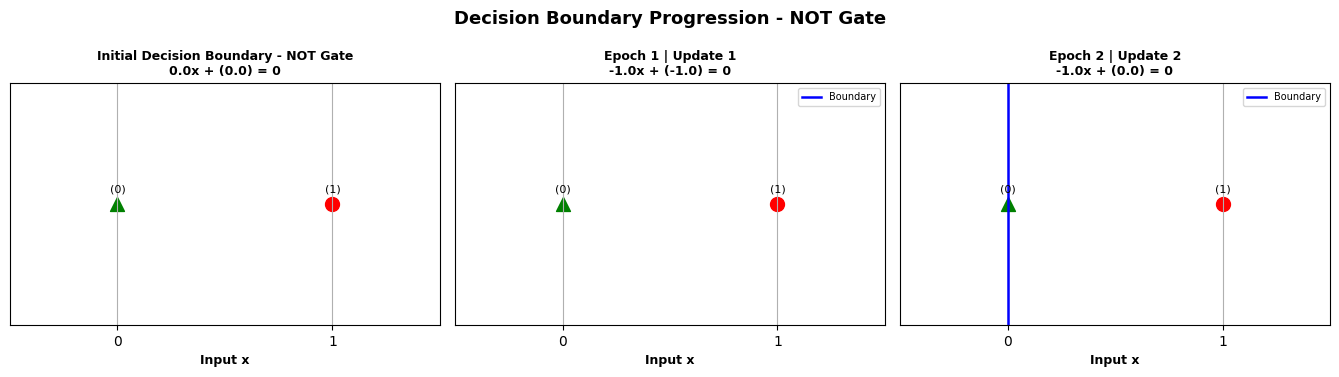

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# PERCEPTRON LEARNING ALGORITHM FOR NOT GATE
# ==========================================================

# Create directory for saving EPS plots
folder_name = "not_eps_plots"
os.makedirs(folder_name, exist_ok=True)

# -----------------------------
# NOT Gate Dataset
# -----------------------------
X = np.array([
    [0],
    [1]
])

y = np.array([1, 0])

# -----------------------------
# Parameters
# -----------------------------
learning_rate = 1
epochs = 10

# Initialize weight and bias
weights = np.zeros(1)
bias = 0

update_no = 0

# Store weight update history
history = []

# Store all decision boundaries for grid plot
plots = []

# -----------------------------
# Step Activation Function
# -----------------------------
def activation(z):
    return 1 if z >= 0 else 0


# -----------------------------
# Helper Function to Save Individual EPS Plot
# -----------------------------
def save_single_plot(w, b, title, filename):
    plt.figure(figsize=(4.5, 4.5))

    colors = ['green' if label == 1 else 'red' for label in y]
    markers = ['^' if label == 1 else 'o' for label in y]

    for i in range(len(X)):
        plt.scatter(
            X[i, 0],
            0,
            color=colors[i],
            marker=markers[i],
            s=120
        )

        plt.text(
            X[i, 0],
            0.05,
            f"({int(X[i, 0])})",
            ha='center',
            fontsize=9
        )

    # Only plot boundary line & legend if weight is non-zero
    if abs(w[0]) > 1e-6:
        boundary = -b / w[0]
        plt.axvline(
            boundary,
            color='blue',
            linewidth=2,
            label="Boundary"
        )
        plt.legend(loc='upper right', fontsize=8)

    equation = f"{w[0]:.1f}x + ({b:.1f}) = 0"

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 0.5)

    plt.xticks([0, 1])
    plt.yticks([])

    plt.xlabel("Input x", fontsize=10, fontweight='bold')
    plt.title(f"{title}\n{equation}", fontsize=11, fontweight='bold')
    plt.grid(True)

    filepath = os.path.join(folder_name, filename)
    plt.savefig(filepath, format="eps", dpi=600, bbox_inches="tight")
    plt.close()


# -----------------------------
# Initial Model
# -----------------------------
print("="*70)
print("INITIAL MODEL - NOT GATE")
print("="*70)

print(f"Weight = {weights}")
print(f"Bias = {bias}")

# Store initial plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Initial Decision Boundary - NOT Gate"
))
save_single_plot(weights, bias, "Initial Decision Boundary - NOT Gate", "initial_boundary.eps")


# -----------------------------
# Perceptron Learning
# -----------------------------
for epoch in range(epochs):

    error_count = 0

    print("\n"+"="*80)
    print(f"EPOCH {epoch+1}")
    print("="*80)

    print(f"{'Input':<10}{'Target':<10}{'Output':<10}{'Error':<10}{'Weight':<20}{'Bias'}")
    print("-"*80)

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        z = np.dot(weights, x) + bias
        prediction = activation(z)

        error = target - prediction

        print(
            f"{str(x):<10}"
            f"{target:<10}"
            f"{prediction:<10}"
            f"{error:<10}"
            f"{str(weights):<20}"
            f"{bias}"
        )

        if error != 0:

            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error

            update_no += 1

            history.append([
                update_no,
                x.copy(),
                target,
                prediction,
                error,
                weights.copy(),
                bias
            ])

            print("\nWeight Updated")
            print(f"New Weight = {weights}")
            print(f"New Bias   = {bias}")

            plot_title = f"Epoch {epoch+1} | Update {update_no}"

            # Store update plot state
            plots.append((
                weights.copy(),
                bias,
                plot_title
            ))

            # Save individual EPS plot
            save_single_plot(weights, bias, plot_title, f"update_{update_no:02d}.eps")

            error_count += 1

    # Epoch Accuracy
    correct = 0

    for i in range(len(X)):
        pred = activation(np.dot(weights, X[i]) + bias)
        if pred == y[i]:
            correct += 1

    accuracy = correct / len(X) * 100

    print(f"\nEpoch {epoch+1} Accuracy = {accuracy:.2f}%")

    if error_count == 0:
        print("\nPerceptron Converged Successfully!")
        break


# -----------------------------
# Weight Update History
# -----------------------------
print("\n")
print("="*95)
print("WEIGHT UPDATE HISTORY")
print("="*95)

print(
    f"{'Upd':<6}"
    f"{'Input':<12}"
    f"{'Target':<10}"
    f"{'Pred':<8}"
    f"{'Error':<8}"
    f"{'Weight':<22}"
    f"{'Bias'}"
)

print("-"*95)

for row in history:

    print(
        f"{row[0]:<6}"
        f"{str(row[1]):<12}"
        f"{row[2]:<10}"
        f"{row[3]:<8}"
        f"{row[4]:<8}"
        f"{str(row[5]):<22}"
        f"{row[6]}"
    )


# -----------------------------
# Final Model
# -----------------------------
print("\n")
print("="*70)
print("FINAL MODEL - NOT GATE")
print("="*70)

print(f"Final Weight = {weights}")
print(f"Final Bias   = {bias}")


# -----------------------------
# Final Predictions
# -----------------------------
print("\n")
print("="*55)
print("FINAL PREDICTIONS")
print("="*55)

print(f"{'Input':<12}{'Target':<12}{'Prediction'}")
print("-"*55)

for i in range(len(X)):

    pred = activation(np.dot(weights, X[i]) + bias)

    print(
        f"{str(X[i]):<12}"
        f"{y[i]:<12}"
        f"{pred}"
    )

# Only add final plot if it differs from the last stored update frame
if plots[-1][0].tolist() != weights.tolist() or plots[-1][1] != bias:
    plots.append((
        weights.copy(),
        bias,
        "Final Decision Boundary - NOT Gate"
    ))
    save_single_plot(weights, bias, "Final Decision Boundary - NOT Gate", "final_boundary.eps")


# ==========================================================
# ALL DECISION BOUNDARIES IN A GRID
# ==========================================================

cols = 3
rows = int(np.ceil(len(plots) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13.5, rows * 3.8))

axes = np.array(axes).reshape(-1)

for ax, (w, b, title) in zip(axes, plots):

    colors = ['green' if label == 1 else 'red' for label in y]
    markers = ['^' if label == 1 else 'o' for label in y]

    for i in range(len(X)):

        ax.scatter(
            X[i, 0],
            0,
            color=colors[i],
            marker=markers[i],
            s=100
        )

        ax.text(
            X[i, 0],
            0.05,
            f"({int(X[i, 0])})",
            ha='center',
            fontsize=8
        )

    # Only plot boundary line & legend if weight is non-zero
    if abs(w[0]) > 1e-6:

        boundary = -b / w[0]

        ax.axvline(
            boundary,
            color='blue',
            linewidth=1.8,
            label="Boundary"
        )

        ax.legend(loc='upper right', fontsize=7)

    equation = f"{w[0]:.1f}x + ({b:.1f}) = 0"

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 0.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([])

    ax.set_xlabel("Input x", fontsize=9, fontweight='bold')

    ax.set_title(f"{title}\n{equation}", fontsize=9, fontweight='bold')

    ax.grid(True)

# Hide unused subplot slots in the grid
for ax in axes[len(plots):]:
    ax.axis("off")

plt.suptitle(
    "Decision Boundary Progression - NOT Gate",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save complete grid plot as vector EPS image
grid_filepath = os.path.join(folder_name, "decision_boundary_progression.eps")
plt.savefig(grid_filepath, format="eps", dpi=600, bbox_inches="tight")

plt.show()

# Experiment 2: Perceptron Learning Algorithm for XOR Gate

## Aim
To implement the Perceptron Learning Algorithm (PLA) for the XOR logic gate using a Single Layer Perceptron (SLP), observe the weight updates after each iteration, visualize the decision boundary after every weight update, and analyze why the algorithm fails to converge.

## Theory
The Perceptron Learning Algorithm (PLA) is a supervised learning algorithm used for binary classification. It learns by adjusting the weights and bias based on the prediction error for each training sample.

For each input, the perceptron computes the weighted sum of the inputs and bias, applies the step activation function, and compares the predicted output with the target output. If the prediction is incorrect, the weights and bias are updated using the perceptron learning rule.

Unlike the AND, OR, and NOT gates, the XOR gate is **not linearly separable**. This means that no single straight line can separate the two output classes. As a result, the Perceptron Learning Algorithm continuously updates the weights without finding a solution that correctly classifies all training samples. Therefore, a Single Layer Perceptron cannot solve the XOR problem, and a Multi-Layer Perceptron (MLP) with at least one hidden layer is required.

## Implementation
The implementation performs the following steps:

- Defines the XOR gate dataset.
- Initializes the weights and bias.
- Uses the step activation function for binary classification.
- Applies the Perceptron Learning Algorithm for a fixed number of epochs.
- Displays the weights and bias after every weight update.
- Calculates the classification accuracy after each epoch.
- Stores and visualizes the decision boundary after every weight update.
- Saves all decision boundary plots as **EPS images with 600 DPI**.
- Displays all decision boundaries together in a grid for better visualization.
- Prints the final model parameters, predictions, and convergence analysis.

## Expected Outcome
The perceptron repeatedly updates its weights but fails to converge because the XOR gate is not linearly separable. The changing decision boundaries clearly illustrate that no single linear boundary can correctly classify all XOR input combinations.

INITIAL MODEL - XOR GATE
Weights = [0. 0.]
Bias = 0

EPOCH 1
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [0. 0.]             0

Weight Updated
New Weights = [0. 0.]
New Bias    = -1
[0 1]     1         0         1         [0. 0.]             -1

Weight Updated
New Weights = [0. 1.]
New Bias    = 0


[1 0]     1         1         0         [0. 1.]             0
[1 1]     0         1         -1        [0. 1.]             0

Weight Updated
New Weights = [-1.  0.]
New Bias    = -1



Epoch 1 Accuracy = 50.00%

EPOCH 2
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         0         0         [-1.  0.]           -1
[0 1]     1         0         1         [-1.  0.]           -1

Weight Updated
New Weights = [-1.  1.]
New Bias    = 0
[1 0]     1         0         1         [-1.  1.]           0

Weight Updated
New Weights = [0. 1.]
New Bias    = 1


[1 1]     0         1         -1        [0. 1.]             1

Weight Updated
New Weights = [-1.  0.]
New Bias    = 0



Epoch 2 Accuracy = 50.00%

EPOCH 3
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [-1.  0.]           0

Weight Updated
New Weights = [-1.  0.]
New Bias    = -1


...


Epoch 9 Accuracy = 50.00%

EPOCH 10
Input     Target    Output    Error     Weights             Bias
--------------------------------------------------------------------------------
[0 0]     0         1         -1        [-1.  0.]           0

Weight Updated
New Weights = [-1.  0.]
New Bias    = -1


[0 1]     1         0         1         [-1.  0.]           -1

Weight Updated
New Weights = [-1.  1.]
New Bias    = 0


[1 0]     1         0         1         [-1.  1.]           0

Weight Updated
New Weights = [0. 1.]
New Bias    = 1


[1 1]     0         1         -1        [0. 1.]             1

Weight Updated
New Weights = [-1.  0.]
New Bias    = 0

Epoch 10 Accuracy = 50.00%


WEIGHT UPDATE HISTORY
Upd   Input       Target    Pred    Error   Weights               Bias
-----------------------------------------------------------------------------------------------
1     [0 0]       0         1       -1      [0. 0.]               -1
2     [0 1]       1         0       1       [0. 1.]               0
3     [1 1]       0         1       -1      [-1.  0.]             -1
4     [0 1]       1         0       1       [-1.  1.]             0
5     [1 0]       1         0       1       [0. 1.]               1
6     [1 1]       0         1       -1      [-1.  0.]             0
7     [0 0]       0         1       -1      [-1.  0.]             -1
8     [0 1]       1         0       1       [-1.  1.]             0
9     [1 0]       1         0       1       [0. 1.]               1
10    [1 1]       0         1       -1      [-1.

[0 0]       0           1
[0 1]       1           1
[1 0]       1           0
[1 1]       0           0


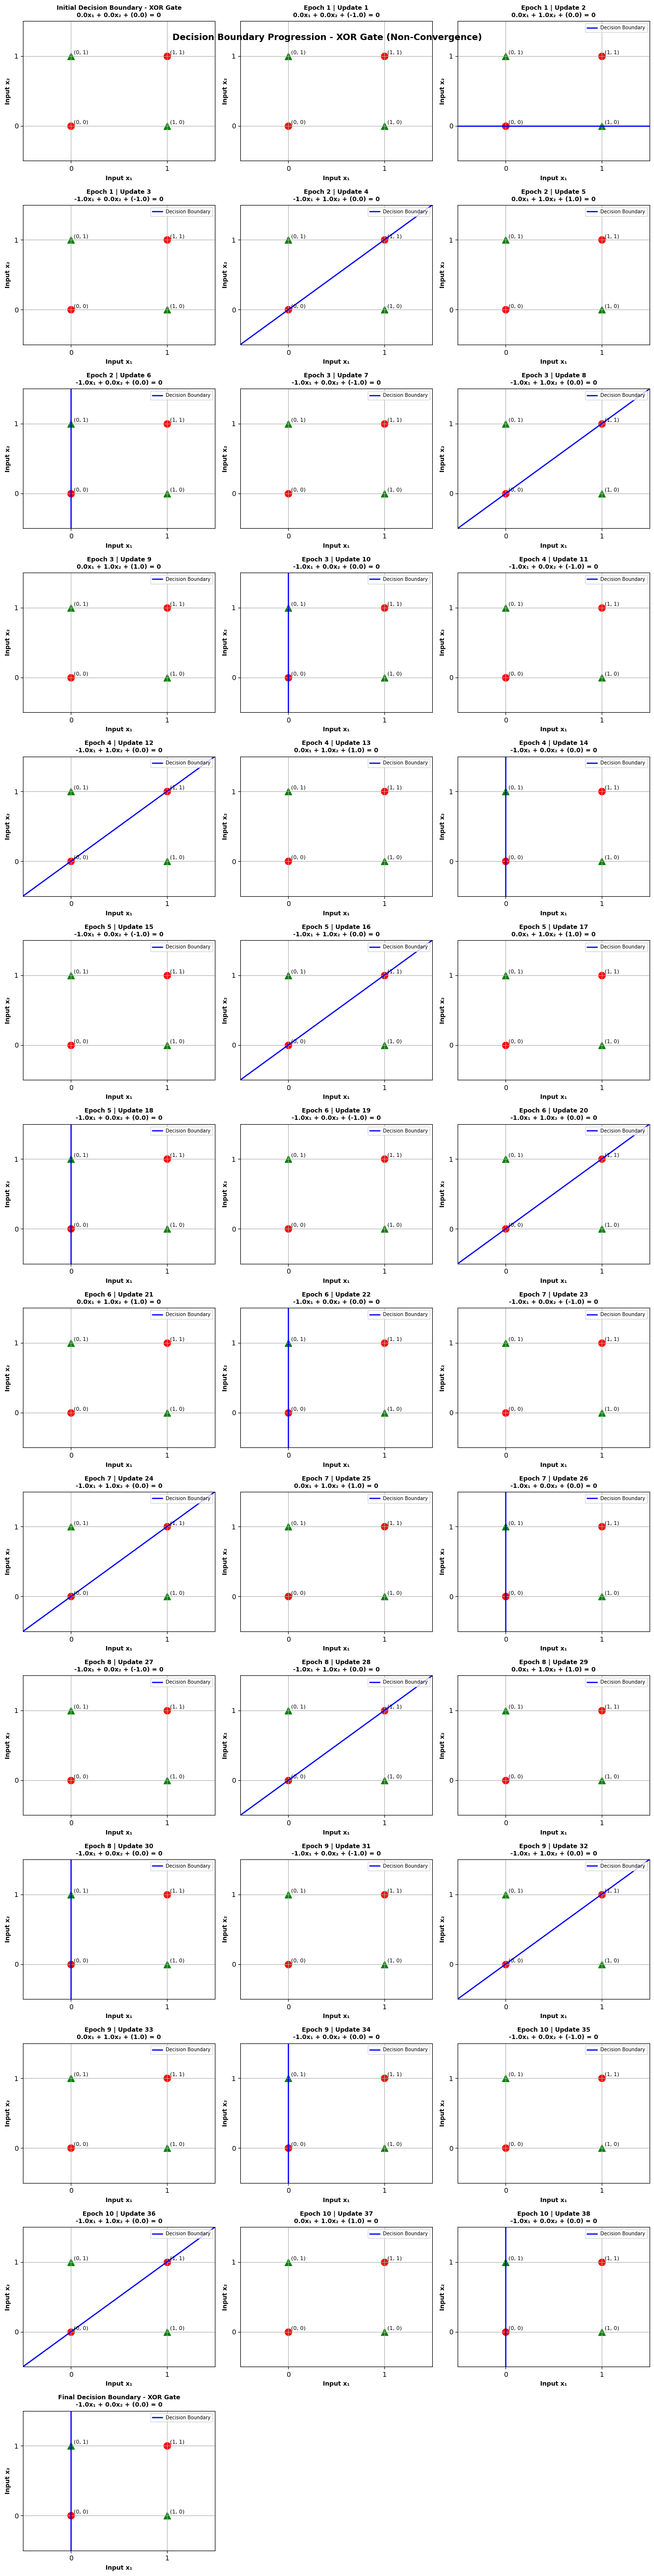

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# PERCEPTRON LEARNING ALGORITHM FOR XOR GATE
# ==========================================================

# Create directory for saving EPS plots
folder_name = "xor_eps_plots"
os.makedirs(folder_name, exist_ok=True)

# -----------------------------
# XOR Gate Dataset
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# -----------------------------
# Parameters
# -----------------------------
learning_rate = 1
epochs = 10

# Initialize weights and bias
weights = np.zeros(2)
bias = 0

update_no = 0

# Store weight update history
history = []

# Store all decision boundaries for grid plot and saving
plots = []

# -----------------------------
# Step Activation Function
# -----------------------------
def activation(z):
    return 1 if z >= 0 else 0


# -----------------------------
# Helper Function to Save EPS Plot
# -----------------------------
def save_single_plot(w, b, title, filename):
    plt.figure(figsize=(4.5, 4.5))

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):
        plt.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=120
        )

        plt.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=9
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:
        y_values = -(w[0] * x_values + b) / w[1]
        plt.plot(
            x_values,
            y_values,
            'b-',
            linewidth=2,
            label="Decision Boundary"
        )
    elif abs(w[0]) > 1e-6:
        x_line = -b / w[0]
        plt.axvline(
            x=x_line,
            color='blue',
            linewidth=2,
            label="Decision Boundary"
        )

    equation = f"{w[0]:.1f}x₁ + {w[1]:.1f}x₂ + ({b:.1f}) = 0"

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xticks([0, 1])
    plt.yticks([0, 1])

    plt.xlabel("Input x₁", fontsize=10, fontweight='bold')
    plt.ylabel("Input x₂", fontsize=10, fontweight='bold')

    plt.title(f"{title}\n{equation}", fontsize=11, fontweight='bold')
    plt.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        plt.legend(loc="upper right", fontsize=8)

    filepath = os.path.join(folder_name, filename)
    plt.savefig(filepath, format="eps", dpi=600, bbox_inches="tight")
    plt.close()


# -----------------------------
# Initial Model
# -----------------------------
print("="*70)
print("INITIAL MODEL - XOR GATE")
print("="*70)
print(f"Weights = {weights}")
print(f"Bias = {bias}")

# Store initial plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Initial Decision Boundary - XOR Gate"
))
save_single_plot(weights, bias, "Initial Decision Boundary - XOR Gate", "initial_boundary.eps")


# -----------------------------
# Perceptron Learning
# -----------------------------
for epoch in range(epochs):

    error_count = 0

    print("\n" + "="*80)
    print(f"EPOCH {epoch+1}")
    print("="*80)

    print(f"{'Input':<10}{'Target':<10}{'Output':<10}{'Error':<10}{'Weights':<20}{'Bias'}")
    print("-"*80)

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        z = np.dot(weights, x) + bias
        prediction = activation(z)

        error = target - prediction

        print(
            f"{str(x):<10}"
            f"{target:<10}"
            f"{prediction:<10}"
            f"{error:<10}"
            f"{str(weights):<20}"
            f"{bias}"
        )

        if error != 0:

            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error

            update_no += 1

            history.append([
                update_no,
                x.copy(),
                target,
                prediction,
                error,
                weights.copy(),
                bias
            ])

            print("\nWeight Updated")
            print(f"New Weights = {weights}")
            print(f"New Bias    = {bias}")

            plot_title = f"Epoch {epoch+1} | Update {update_no}"

            # Store update plot state
            plots.append((
                weights.copy(),
                bias,
                plot_title
            ))

            # Save individual EPS plot for this update
            save_single_plot(weights, bias, plot_title, f"update_{update_no:02d}.eps")

            error_count += 1

    # Accuracy after epoch
    correct = 0

    for i in range(len(X)):
        pred = activation(np.dot(weights, X[i]) + bias)
        if pred == y[i]:
            correct += 1

    accuracy = correct / len(X) * 100

    print(f"\nEpoch {epoch+1} Accuracy = {accuracy:.2f}%")

    if error_count == 0:
        print("\nPerceptron Converged Successfully!")
        break


# -----------------------------
# Weight Update History
# -----------------------------
print("\n")
print("="*95)
print("WEIGHT UPDATE HISTORY")
print("="*95)

print(
    f"{'Upd':<6}"
    f"{'Input':<12}"
    f"{'Target':<10}"
    f"{'Pred':<8}"
    f"{'Error':<8}"
    f"{'Weights':<22}"
    f"{'Bias'}"
)

print("-"*95)

for row in history:

    print(
        f"{row[0]:<6}"
        f"{str(row[1]):<12}"
        f"{row[2]:<10}"
        f"{row[3]:<8}"
        f"{row[4]:<8}"
        f"{str(row[5]):<22}"
        f"{row[6]}"
    )


# -----------------------------
# Final Model
# -----------------------------
print("\n")
print("="*70)
print("FINAL MODEL - XOR GATE")
print("="*70)

print(f"Final Weights = {weights}")
print(f"Final Bias    = {bias}")


# -----------------------------
# Final Predictions
# -----------------------------
print("\n")
print("="*55)
print("FINAL PREDICTIONS")
print("="*55)

print(f"{'Input':<12}{'Target':<12}{'Prediction'}")
print("-"*55)

for i in range(len(X)):

    pred = activation(np.dot(weights, X[i]) + bias)

    print(
        f"{str(X[i]):<12}"
        f"{y[i]:<12}"
        f"{pred}"
    )

# Store final plot state & save EPS
plots.append((
    weights.copy(),
    bias,
    "Final Decision Boundary - XOR Gate"
))
save_single_plot(weights, bias, "Final Decision Boundary - XOR Gate", "final_boundary.eps")


# ==========================================================
# ALL DECISION BOUNDARIES IN A GRID (3 COLUMNS)
# ==========================================================

cols = 3
rows = int(np.ceil(len(plots) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(13.5, rows * 3.8))

axes = np.array(axes).reshape(-1)

for ax, (w, b, title) in zip(axes, plots):

    colors = ['red' if label == 0 else 'green' for label in y]
    markers = ['o' if label == 0 else '^' for label in y]

    for i in range(len(X)):

        ax.scatter(
            X[i, 0],
            X[i, 1],
            color=colors[i],
            marker=markers[i],
            s=100
        )

        ax.text(
            X[i, 0] + 0.03,
            X[i, 1] + 0.03,
            f"({int(X[i, 0])}, {int(X[i, 1])})",
            fontsize=8
        )

    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(w[1]) > 1e-6:

        y_values = -(w[0] * x_values + b) / w[1]

        ax.plot(
            x_values,
            y_values,
            'b-',
            linewidth=1.8,
            label="Decision Boundary"
        )

    elif abs(w[0]) > 1e-6:

        x_line = -b / w[0]

        ax.axvline(
            x=x_line,
            color='blue',
            linewidth=1.8,
            label="Decision Boundary"
        )

    equation = (
        f"{w[0]:.1f}x₁ + "
        f"{w[1]:.1f}x₂ + "
        f"({b:.1f}) = 0"
    )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xlabel("Input x₁", fontsize=9, fontweight='bold')
    ax.set_ylabel("Input x₂", fontsize=9, fontweight='bold')

    ax.set_title(
        f"{title}\n{equation}",
        fontsize=9,
        fontweight='bold'
    )

    ax.grid(True)

    if abs(w[0]) > 1e-6 or abs(w[1]) > 1e-6:
        ax.legend(loc="upper right", fontsize=7)

# Hide unused subplot axes
for ax in axes[len(plots):]:
    ax.axis("off")

plt.suptitle(
    "Decision Boundary Progression - XOR Gate (Non-Convergence)",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save complete grid plot as vector EPS image
grid_filepath = os.path.join(folder_name, "decision_boundary_progression.eps")
plt.savefig(grid_filepath, format="eps", dpi=600, bbox_inches="tight")

plt.show()